# Chapter 7. Data Cleaning and Preparation

## 7.1 Handling Missing Data
- All of the descriptive statistics on pandas objects exclude missing data by default.
- For Numeric data, pandas uses the floating-point value **NaN** (Not a Number) to represent missing data.
- By refering to missing data as **NA**, which stands for *not available*. NA data may either be data that does not exist or that exists but was not observed.
- The built-in Python **None** value is also treated as NA in in object arrays:

In [1]:
import numpy as np
import pandas as pd

In [3]:
string_data = pd.Series(['aa', 'bb', np.nan, 'cc'])
string_data.isnull()

0    False
1    False
2     True
3    False
dtype: bool

In [4]:
string_data[0] = None
string_data.isnull()

0     True
1    False
2     True
3    False
dtype: bool

> 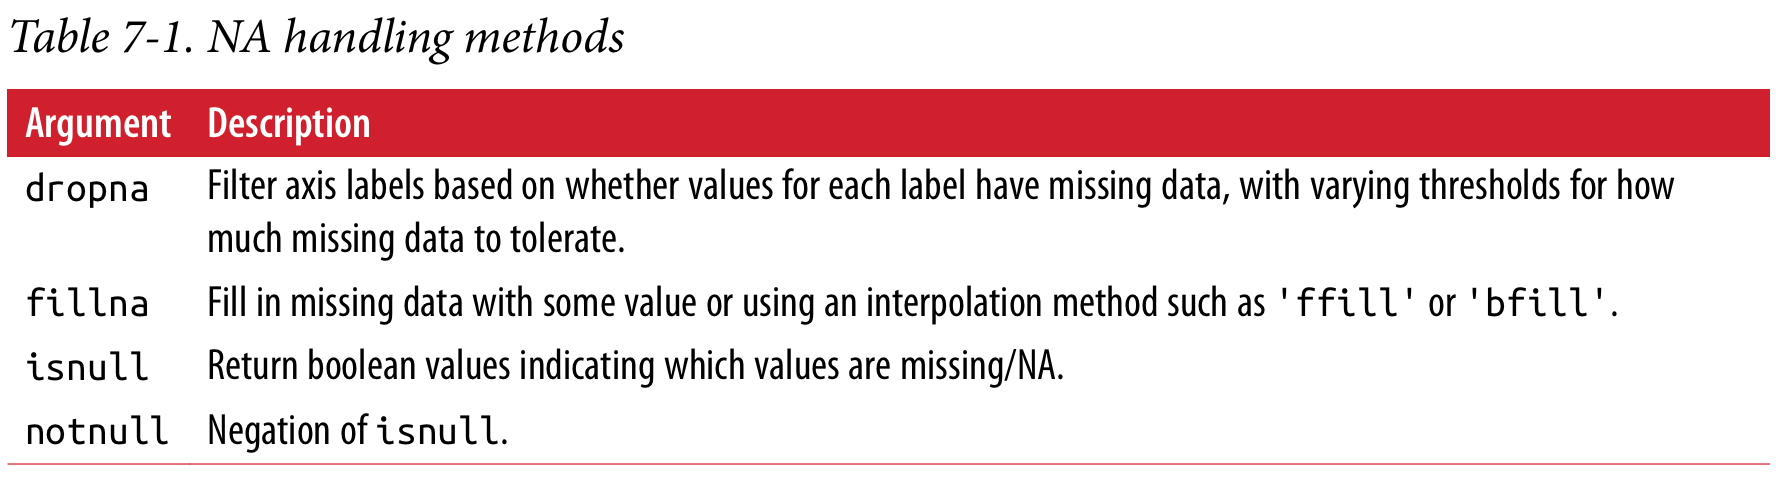

### Filtering Out Missing Data
> ***dropna*** : **On a Series**, it returns the Series with only the non-null data and index values:

In [10]:
data = pd.Series([1, np.nan, 3.5, np.nan, 7])
data.dropna()

0    1.0
2    3.5
4    7.0
dtype: float64

> **On a DataFrame**, *dropna* by default **drops any row containing a missing value** 

In [2]:
data = pd.DataFrame([[1.,6.5,3.],[1,np.nan,np.nan],
                    [np.nan,np.nan,np.nan],[np.nan,6.5,3]])
data

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


In [3]:
data.dropna()

,0,1,2
0,1.0,6.5,3.0


> - Passing **how = 'all'** will only drop rows that are all NA:

In [4]:
data.dropna(how='all')

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
3,NaN,6.5,3.0


> - To drop columns in the same way, pass **axis = 1**:

In [5]:
data[4] = np.nan
data

,0,1,2,4
0,1.0,6.5,3.0,NaN
1,1.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,6.5,3.0,NaN


In [6]:
data.dropna(how='all', axis = 1)

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


> - To keep only rows containing a certain number of observations -> Use ***thresh*** 

In [21]:
df = pd.DataFrame(np.random.randn(7,3))
df.iloc[:4, 1] = np.nan
df.iloc[:2, 2] = np.nan
df

,0,1,2
0,0.681552,NaN,NaN
1,1.869648,NaN,NaN
2,-0.563461,NaN,0.153989
3,-0.784937,NaN,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


In [22]:
df.dropna(thresh=3)

,0,1,2
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


### Filling in Missing Data
> - Calling *fillna* with a **dict**, you can use a different fill value for each column:

In [23]:
df.fillna({1:0.5, 2:0}) #return new object, 원 Df 변경 없음

,0,1,2
0,0.681552,0.500000,0.000000
1,1.869648,0.500000,0.000000
2,-0.563461,0.500000,0.153989
3,-0.784937,0.500000,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


In [24]:
df

,0,1,2
0,0.681552,NaN,NaN
1,1.869648,NaN,NaN
2,-0.563461,NaN,0.153989
3,-0.784937,NaN,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


> 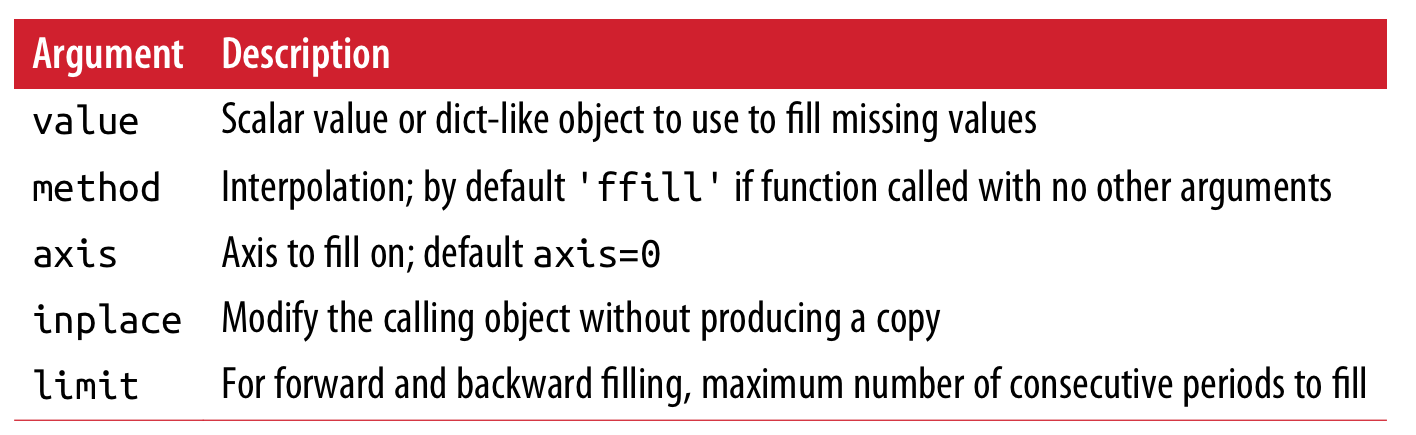

In [25]:
df.fillna(0, limit=2, inplace=True)
df # inplace 조건으로 원 DataFrame 변경

,0,1,2
0,0.681552,0.000000,0.000000
1,1.869648,0.000000,0.000000
2,-0.563461,NaN,0.153989
3,-0.784937,NaN,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371
